In [ ]:
#importante lembrar de substituir as etapas de importacao com os locais corretos dentro do seu ambiente
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/A3')
os.listdir()

['diabetes.csv', 'A3ANNLog.ipynb', 'A3DT.ipynb']

In [ ]:
#importa bibliotecas para o desenvolvimento do trabalho
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Le o arquivo CSV e armazena em um dataframe Pandas
data = pd.read_csv('diabetes.csv')
# Mostra a quantidade de linhas e colunas do dataset antes das alteracoes
print("Antes da limpeza:", data.shape)

Antes da limpeza: (768, 9)


In [ ]:
#colunas onde o valor 0 nao faz sentido (mostra que o dado nao foi coletado corretamente)
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [ ]:
#cria uma copia segura do DataFrame original
data_clean = data.copy()
#passa por cada uma das colunas listadas acima
for col in cols:
#mantem apenas as linhas onde o valor da coluna seja diferente de 0
    data_clean = data_clean[data_clean[col] != 0]
print("Depois da remoção de zeros:", data_clean.shape)

Depois da remoção de zeros: (392, 9)


In [ ]:
#lista todas as colunas que fazem parte da analise de outliers
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
#calcula o Z-score absoluto para cada elemento das colunas selecionadas
z = np.abs(stats.zscore(data_clean[num_cols]))
#(z < 3) identificar elementos dentro do limite
#.all(axis=1) garante que a linha inteira seja mantida se as suas colunas forem validas
data_clean = data_clean[(z < 3).all(axis=1)]
print("Após remover outliers:", data_clean.shape)

Após remover outliers: (365, 9)


In [ ]:
#X recebe os dados para a predicao
X = data_clean.drop('Outcome', axis=1)
#y recebe a variavel alvo
y = data_clean['Outcome']


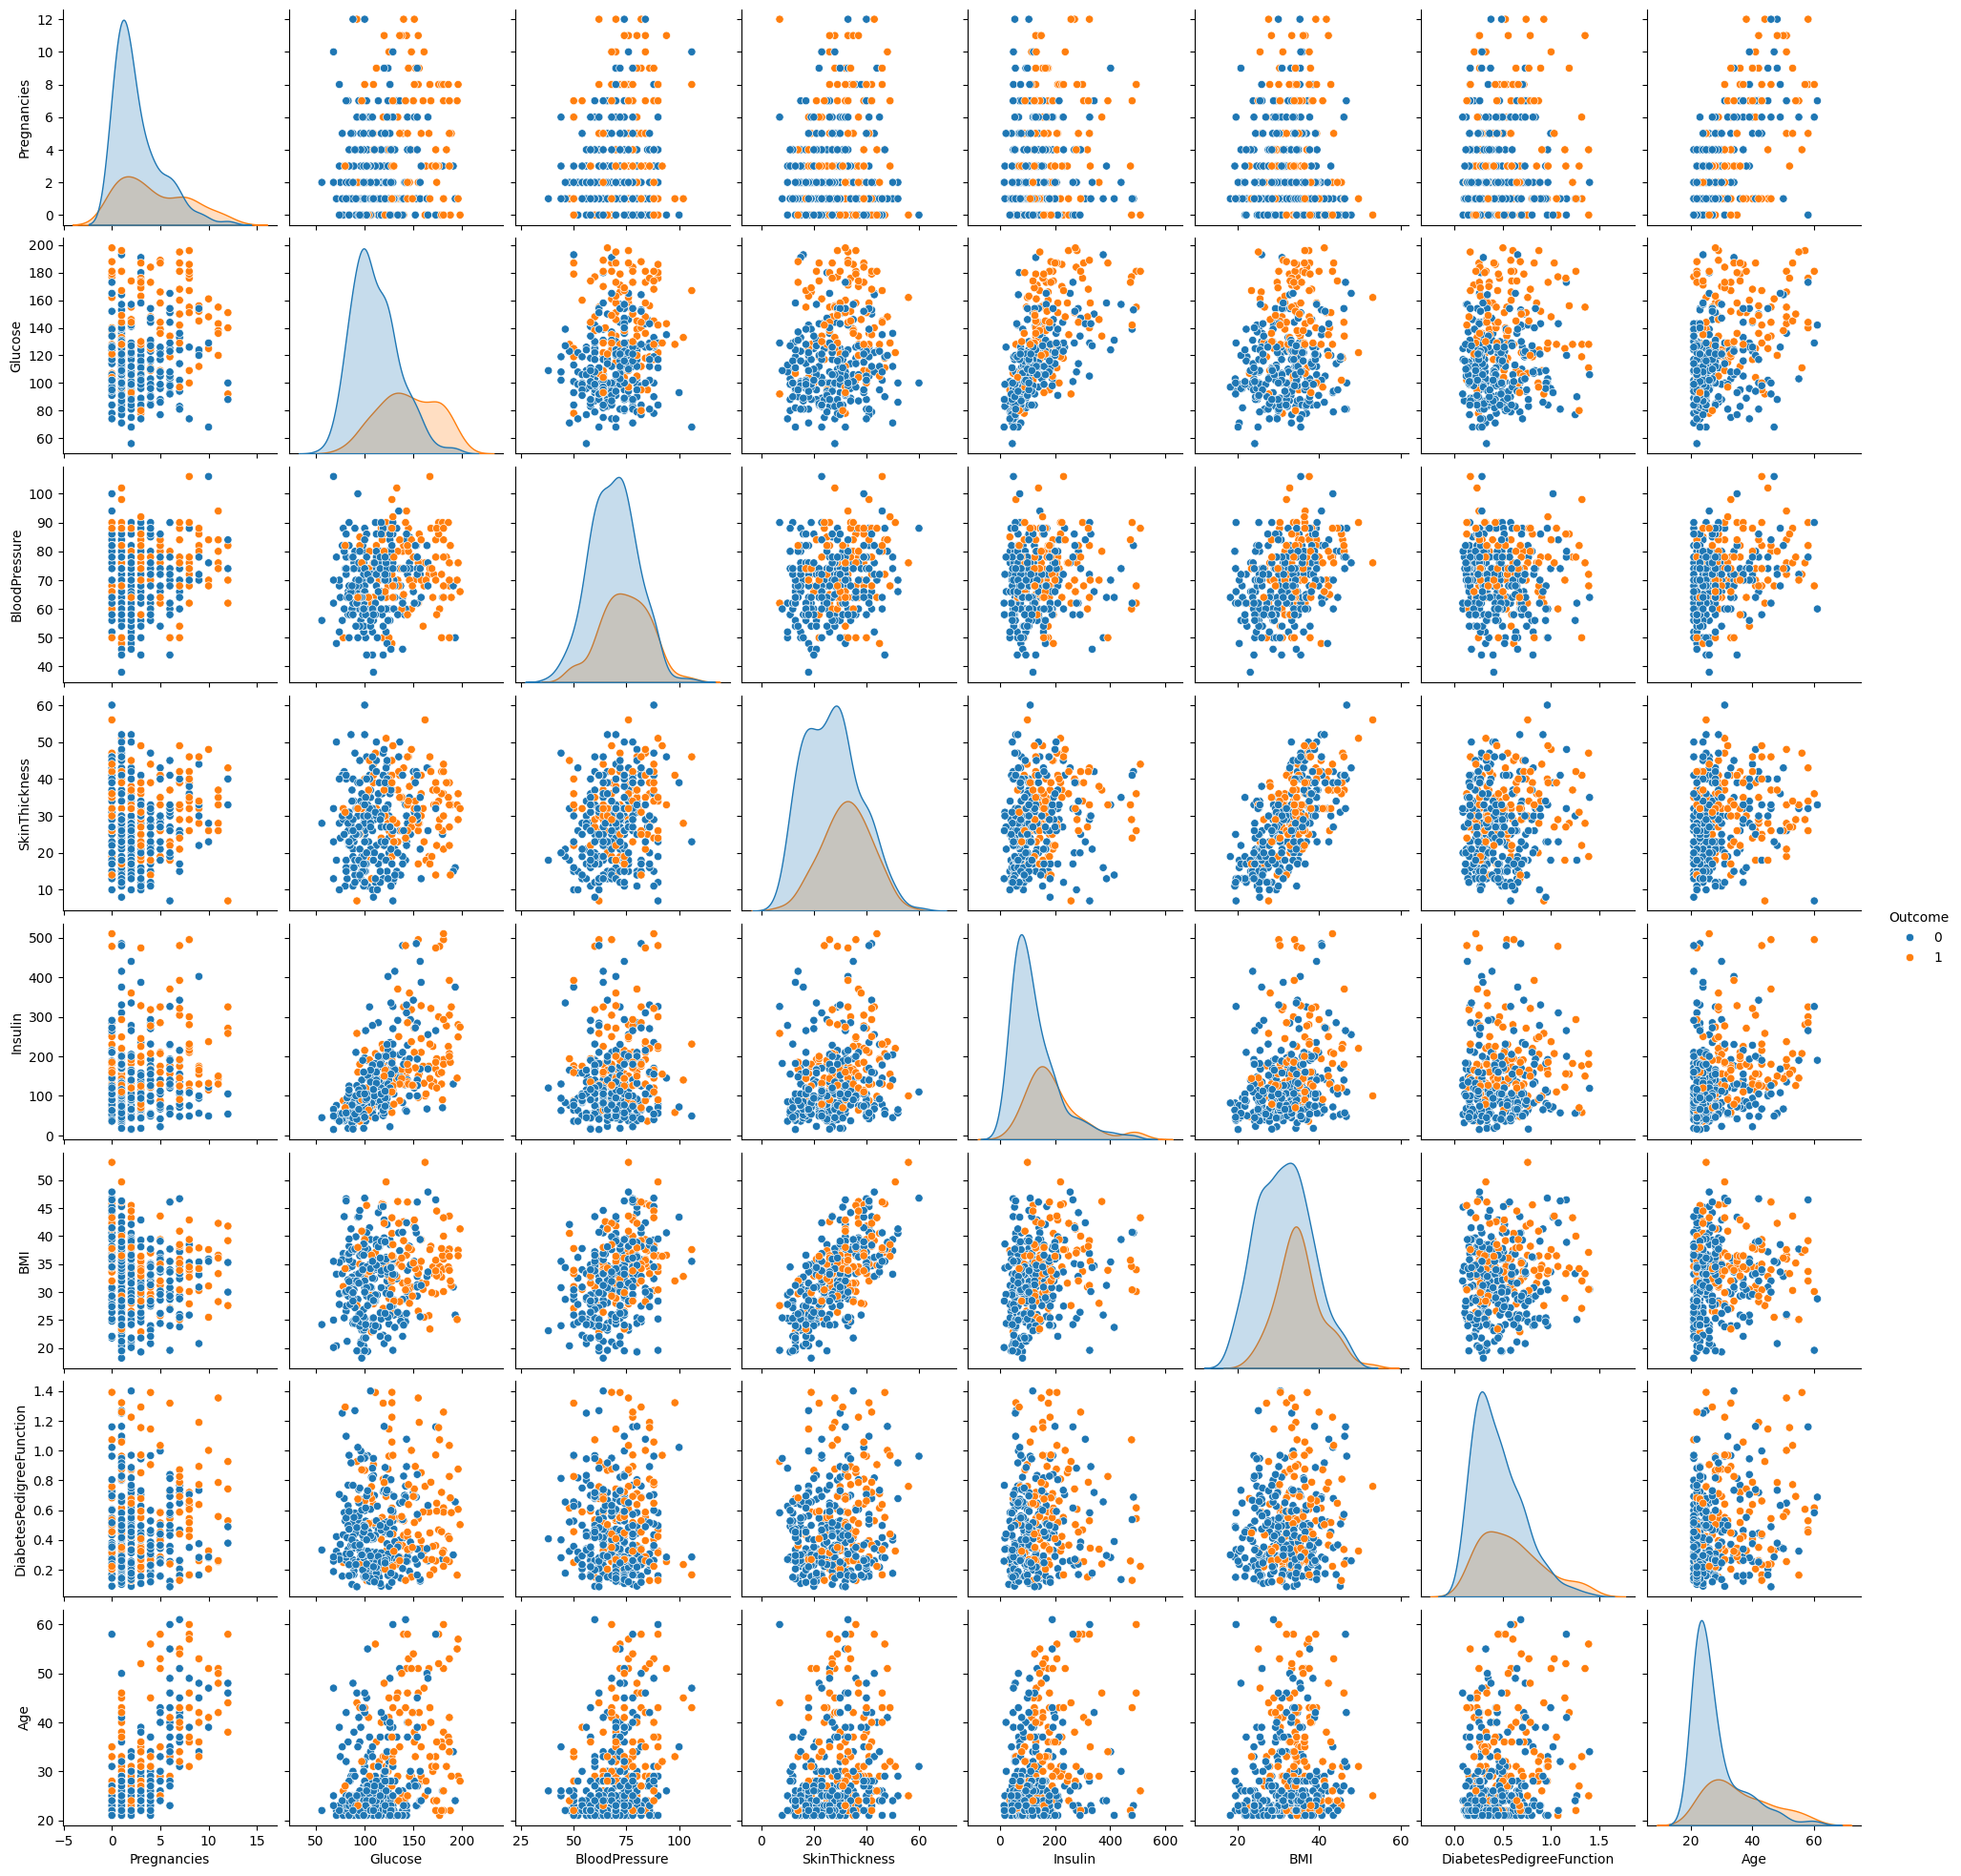

In [ ]:
sns.pairplot(data_clean, hue='Outcome')

<Axes: xlabel='Glucose', ylabel='Count'>

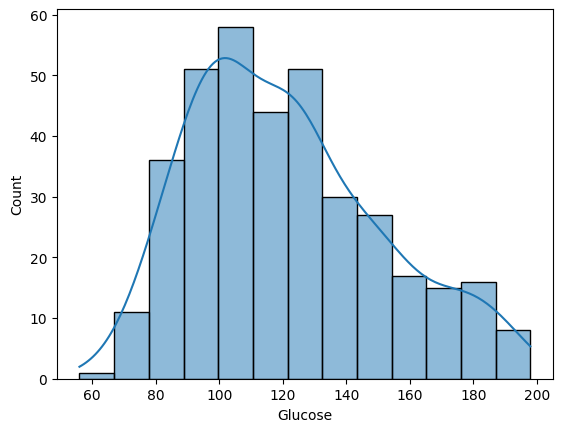

In [ ]:
sns.histplot(data_clean['Glucose'], kde=True)

<Axes: xlabel='Glucose', ylabel='Insulin'>

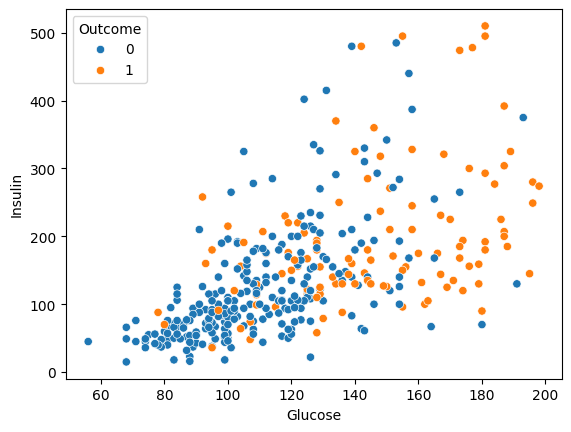

In [ ]:
sns.scatterplot(x='Glucose', y='Insulin', hue='Outcome', data=data_clean)

In [ ]:
#separa os dados em 80% para treinamento e 20% para testes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=58)

In [ ]:
#inicializa o MinMaxScaler
scaler = MinMaxScaler()

#o scaler "aprende" o mínimo e máximo do treino e já padroniza os dados
X_train = scaler.fit_transform(X_train)

#padroniza os dados de teste
X_test = scaler.transform(X_test)

In [ ]:
#cria o esqueleto do modelo
model = Sequential()

#define as camadas ocultas com ativacao relu
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
#define a camada de saida com sigmoid para obter resultado
model.add(Dense(1, activation='sigmoid'))

# compila a rede para inicar o treinamento
model.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
#inicia aprendizado de maquina
model.fit(x=X_train,
          y=y_train.values,
          validation_data=(X_test, y_test.values),      # checa erro nos dados a cada ciclo
          batch_size=48,                                # quantidade de calculos para chegar no melhor valor dos pesos
          epochs=250)                                   # quantidade de epocas

Epoch 1/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.7146 - val_loss: 0.7084
Epoch 2/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7005 - val_loss: 0.6877
Epoch 3/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6874 - val_loss: 0.6714
Epoch 4/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6786 - val_loss: 0.6571
Epoch 5/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6719 - val_loss: 0.6481
Epoch 6/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6663 - val_loss: 0.6404
Epoch 7/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6620 - val_loss: 0.6308
Epoch 8/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6570 - val_loss: 0.6220
Epoch 9/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6530 - val_loss: 0.6106
Epoch 10/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6480 - val_loss: 0.6000
Epoch 11/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6434 - val_loss: 0.5890
Epoch 12/250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6384 - val_lo

<Axes: >

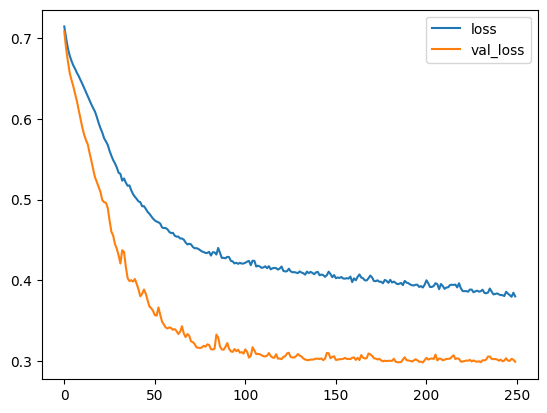

In [ ]:
# salva o historico de erros durante as epocas
loss = pd.DataFrame(model.history.history)
# plota o gráfico de erro
loss.plot()

In [ ]:
# tenta prever a probabilidade de diabetes para os pacientes de teste
y_pred = model.predict(X_test)

# converte probabilidade para true or false
y_pred = (y_pred > 0.5)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
#exibe metricas de acerto e a matriz de confusao
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        56
           1       0.69      0.53      0.60        17

    accuracy                           0.84        73
   macro avg       0.78      0.73      0.75        73
weighted avg       0.83      0.84      0.83        73

[[52  4]
 [ 8  9]]
